# Trabajo Práctico II - Visión por Computadora I

Alumnos:
- Maximiliano Christener
- Ronald Uthurralt
- Luis David Díaz Charris
- Juan Pablo Skobalski

Se implementa la métrica FM (Frequency Domain Image Blur Measure) propuesta en el paper
"Image Sharpness Measure for Blurred Images in Frequency Domain" (Kanjar De, V. Masilamani, 2013).

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
def compute_fm(image_gray):
    f = np.fft.fft2(image_gray.astype(np.float64))
    fc = np.fft.fftshift(f)
    af = np.abs(fc)
    m = np.max(af)
    thres = m / 1000
    t_h = np.sum(af > thres)
    rows, cols = image_gray.shape
    fm = t_h / (rows * cols)
    return fm

In [4]:
def detect_max_focus(fm_values):
    fm_array = np.array(fm_values)
    max_idx = np.argmax(fm_array)
    return max_idx, fm_array[max_idx]

In [5]:
VIDEO_PATH = 'material/focus_video.mov'

cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f'Total frames: {total_frames}')
print(f'FPS: {fps}')
print(f'Resolución: {width}x{height}')

frames_gray = []
frames_color = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames_color.append(frame)
    frames_gray.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
cap.release()

print(f'Frames leídos: {len(frames_gray)}')

Total frames: 171
FPS: 29.97002997002997
Resolución: 640x360
Frames leídos: 171


## Experimento 1: Medición sobre todo el frame

In [6]:
fm_full = [compute_fm(frame) for frame in frames_gray]

max_frame_full, max_fm_full = detect_max_focus(fm_full)
print(f'Frame de máximo enfoque: {max_frame_full}')
print(f'Valor FM máximo: {max_fm_full:.4f}')

Frame de máximo enfoque: 109
Valor FM máximo: 0.0278


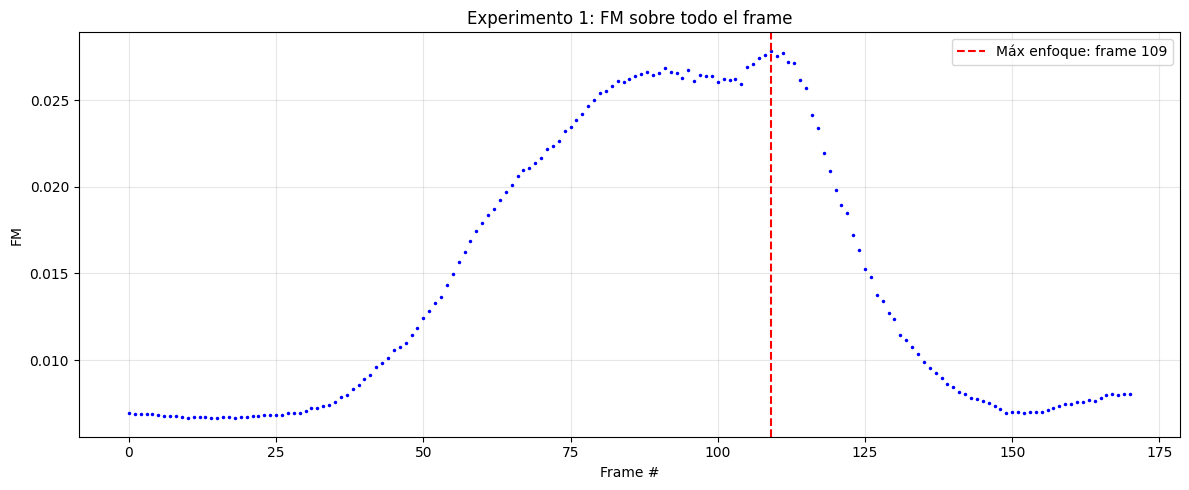

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fm_full, 'b.', markersize=3)
ax.axvline(x=max_frame_full, color='r', linestyle='--', label=f'Máx enfoque: frame {max_frame_full}')
ax.set_xlabel('Frame #')
ax.set_ylabel('FM')
ax.set_title('Experimento 1: FM sobre todo el frame')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

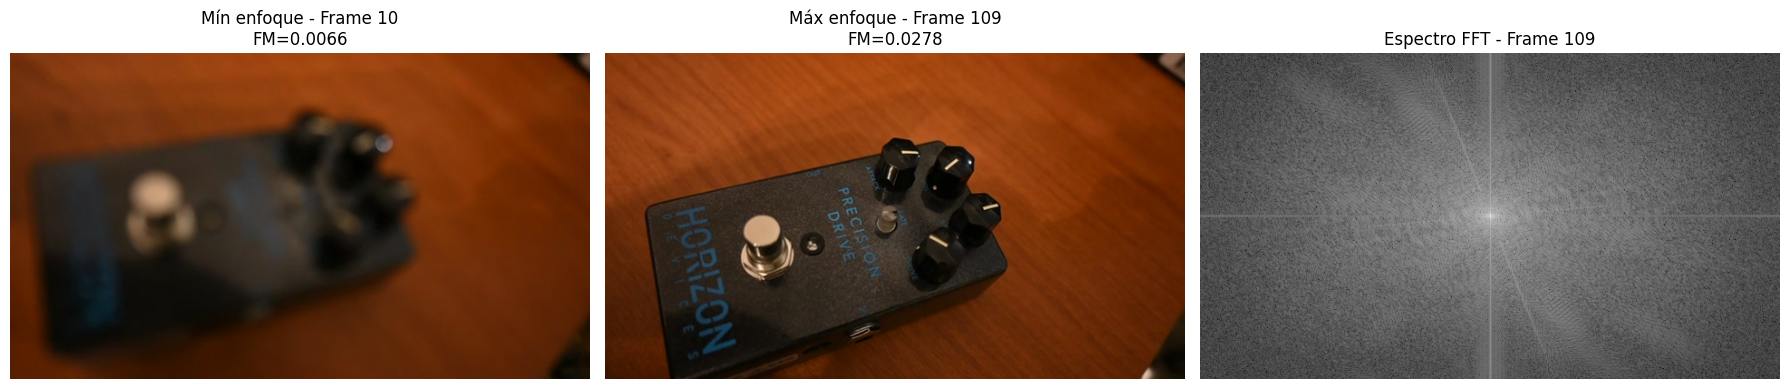

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Frame min FM
min_frame = np.argmin(fm_full)
axes[0].imshow(cv2.cvtColor(frames_color[min_frame], cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Mín enfoque - Frame {min_frame}\nFM={fm_full[min_frame]:.4f}')
axes[0].axis('off')

# Frame max enfoque
axes[1].imshow(cv2.cvtColor(frames_color[max_frame_full], cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Máx enfoque - Frame {max_frame_full}\nFM={max_fm_full:.4f}')
axes[1].axis('off')

# Espectro de frecuencia del frame de maximo enfoque
f = np.fft.fft2(frames_gray[max_frame_full].astype(np.float64))
fc = np.fft.fftshift(f)
magnitude = 20 * np.log(np.abs(fc) + 1)
axes[2].imshow(magnitude, cmap='gray')
axes[2].set_title(f'Espectro FFT - Frame {max_frame_full}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Cuando miramos el video, podemos notar que comienza desefocado y a medida que van pasando los frames el video se comienza a enfocar el objeto, para luego volver a desenfocarse. Lo mismo se ve en el gráfico, donde el frame de maximo enfoque es el 109. Podemos afirmar que el algoritmo utilizado en el experimento 1, mostro una gran eficacia para detectar el frame de maximo enfoque.

## Experimento 2: Medición sobre ROI central (5% y 10% del área total)

En este experimento, a diferencia del anterior, reducimos el área de análisis recortándola a una sección pequeña del centro del frame. El objetivo es concentrar la medición en la zona donde típicamente se encuentra el objeto de interés, reduciendo el ruido que pueden generar objetos o secciones por fuera del objeto.

In [9]:
def extract_center_roi(image, area_ratio):
    h, w = image.shape[:2]
    scale = np.sqrt(area_ratio)
    roi_w = int(w * scale)
    roi_h = int(h * scale)
    x_start = (w - roi_w) // 2
    y_start = (h - roi_h) // 2
    return image[y_start:y_start+roi_h, x_start:x_start+roi_w]

In [10]:
fm_roi_5 = [compute_fm(extract_center_roi(frame, 0.05)) for frame in frames_gray]
fm_roi_10 = [compute_fm(extract_center_roi(frame, 0.10)) for frame in frames_gray]

max_frame_5, max_fm_5 = detect_max_focus(fm_roi_5)
max_frame_10, max_fm_10 = detect_max_focus(fm_roi_10)

print(f'ROI 5%  - Frame máx enfoque: {max_frame_5}, FM={max_fm_5:.4f}')
print(f'ROI 10% - Frame máx enfoque: {max_frame_10}, FM={max_fm_10:.4f}')

ROI 5%  - Frame máx enfoque: 111, FM=0.4596
ROI 10% - Frame máx enfoque: 111, FM=0.3531


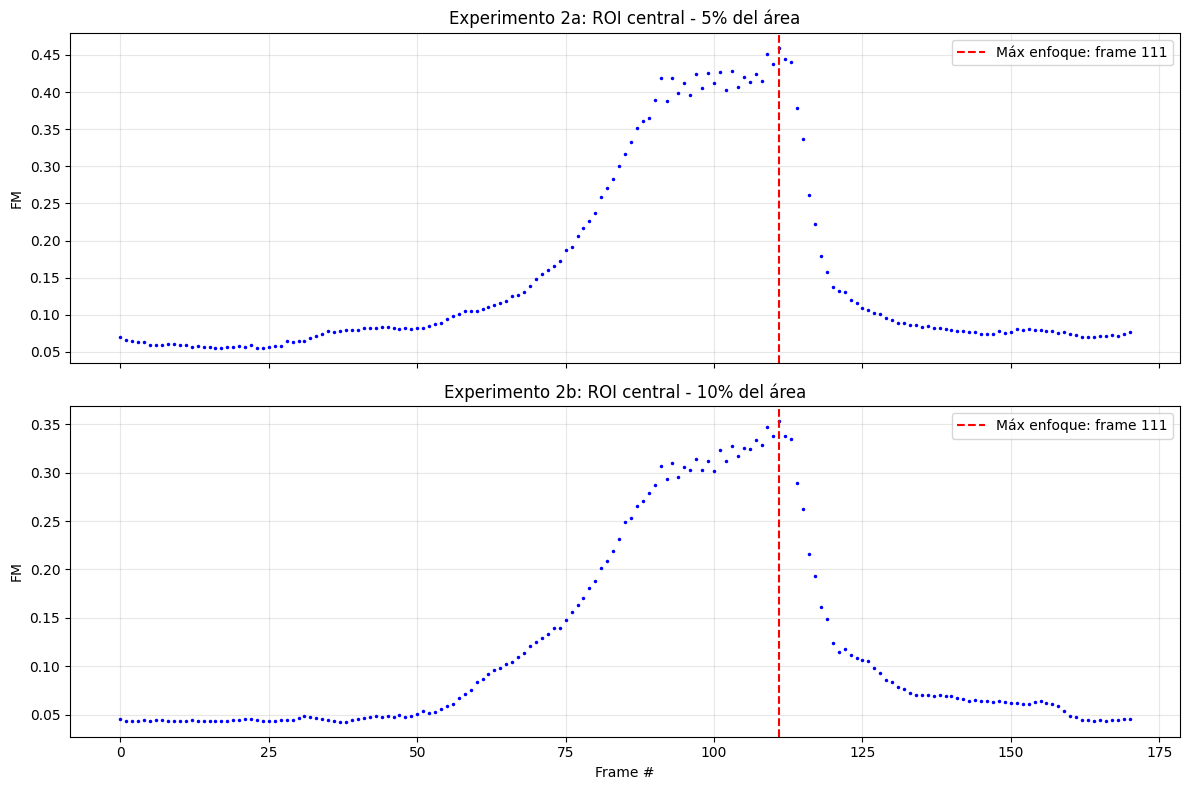

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(fm_roi_5, 'b.', markersize=3)
axes[0].axvline(x=max_frame_5, color='r', linestyle='--', label=f'Máx enfoque: frame {max_frame_5}')
axes[0].set_ylabel('FM')
axes[0].set_title('Experimento 2a: ROI central - 5% del área')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fm_roi_10, 'b.', markersize=3)
axes[1].axvline(x=max_frame_10, color='r', linestyle='--', label=f'Máx enfoque: frame {max_frame_10}')
axes[1].set_xlabel('Frame #')
axes[1].set_ylabel('FM')
axes[1].set_title('Experimento 2b: ROI central - 10% del área')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

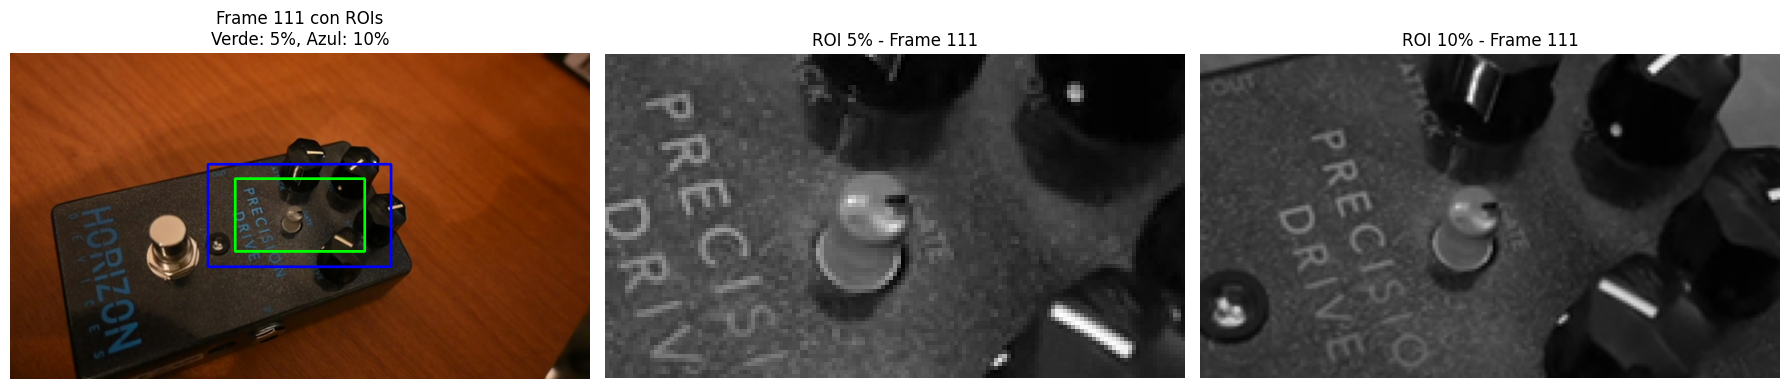

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

frame_show = frames_color[max_frame_10].copy()
h, w = frame_show.shape[:2]

# ROI 5%
s5 = np.sqrt(0.05)
x5, y5 = int(w*(1-s5)/2), int(h*(1-s5)/2)
w5, h5 = int(w*s5), int(h*s5)
cv2.rectangle(frame_show, (x5, y5), (x5+w5, y5+h5), (0, 255, 0), 2)

# ROI 10%
s10 = np.sqrt(0.10)
x10, y10 = int(w*(1-s10)/2), int(h*(1-s10)/2)
w10, h10 = int(w*s10), int(h*s10)
cv2.rectangle(frame_show, (x10, y10), (x10+w10, y10+h10), (255, 0, 0), 2)

axes[0].imshow(cv2.cvtColor(frame_show, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Frame {max_frame_10} con ROIs\nVerde: 5%, Azul: 10%')
axes[0].axis('off')

roi_5_img = extract_center_roi(frames_gray[max_frame_5], 0.05)
axes[1].imshow(roi_5_img, cmap='gray')
axes[1].set_title(f'ROI 5% - Frame {max_frame_5}')
axes[1].axis('off')

roi_10_img = extract_center_roi(frames_gray[max_frame_10], 0.10)
axes[2].imshow(roi_10_img, cmap='gray')
axes[2].set_title(f'ROI 10% - Frame {max_frame_10}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Como podemos observar en los graficos y en la imágenes, el enfoque es muy similar al del experimento 1, llegando a identificar al frame 111 como el de maximo enfoque.

## Experimento 3 (Opcional): Matriz de enfoque NxM

En este experimento se divide cada frame en una matriz de N×M celdas y se calcula la métrica FM de forma independiente para cada una. Esto permite obtener un mapa de enfoque, identificando qué celdas del frame están más enfocadas y cuáles no. Decidimos utilizar los siguientes tamaños de matrices:
- 3x3
- 5x7
- 7x7

In [13]:
def compute_focus_matrix(frame_gray, rows, cols):
    h, w = frame_gray.shape
    cell_h = h // rows
    cell_w = w // cols
    
    matrix = np.zeros((rows, cols))
    for i in range(rows):
        for j in range(cols):
            cell = frame_gray[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            matrix[i, j] = compute_fm(cell)
    return matrix

In [14]:
matrix = [(3, 3), (5, 7), (7, 7)]

fm_matrix_results = {}
for (gr, gc) in matrix:
    key = f'{gr}x{gc}'
    fm_means = []
    for frame in frames_gray:
        mat = compute_focus_matrix(frame, gr, gc)
        fm_means.append(np.mean(mat))
    fm_matrix_results[key] = fm_means
    max_f, max_v = detect_max_focus(fm_means)
    print(f'Matriz {key} - Frame máx enfoque: {max_f}, FM medio={max_v:.4f}')

Matriz 3x3 - Frame máx enfoque: 111, FM medio=0.1235
Matriz 5x7 - Frame máx enfoque: 111, FM medio=0.1993
Matriz 7x7 - Frame máx enfoque: 111, FM medio=0.2279


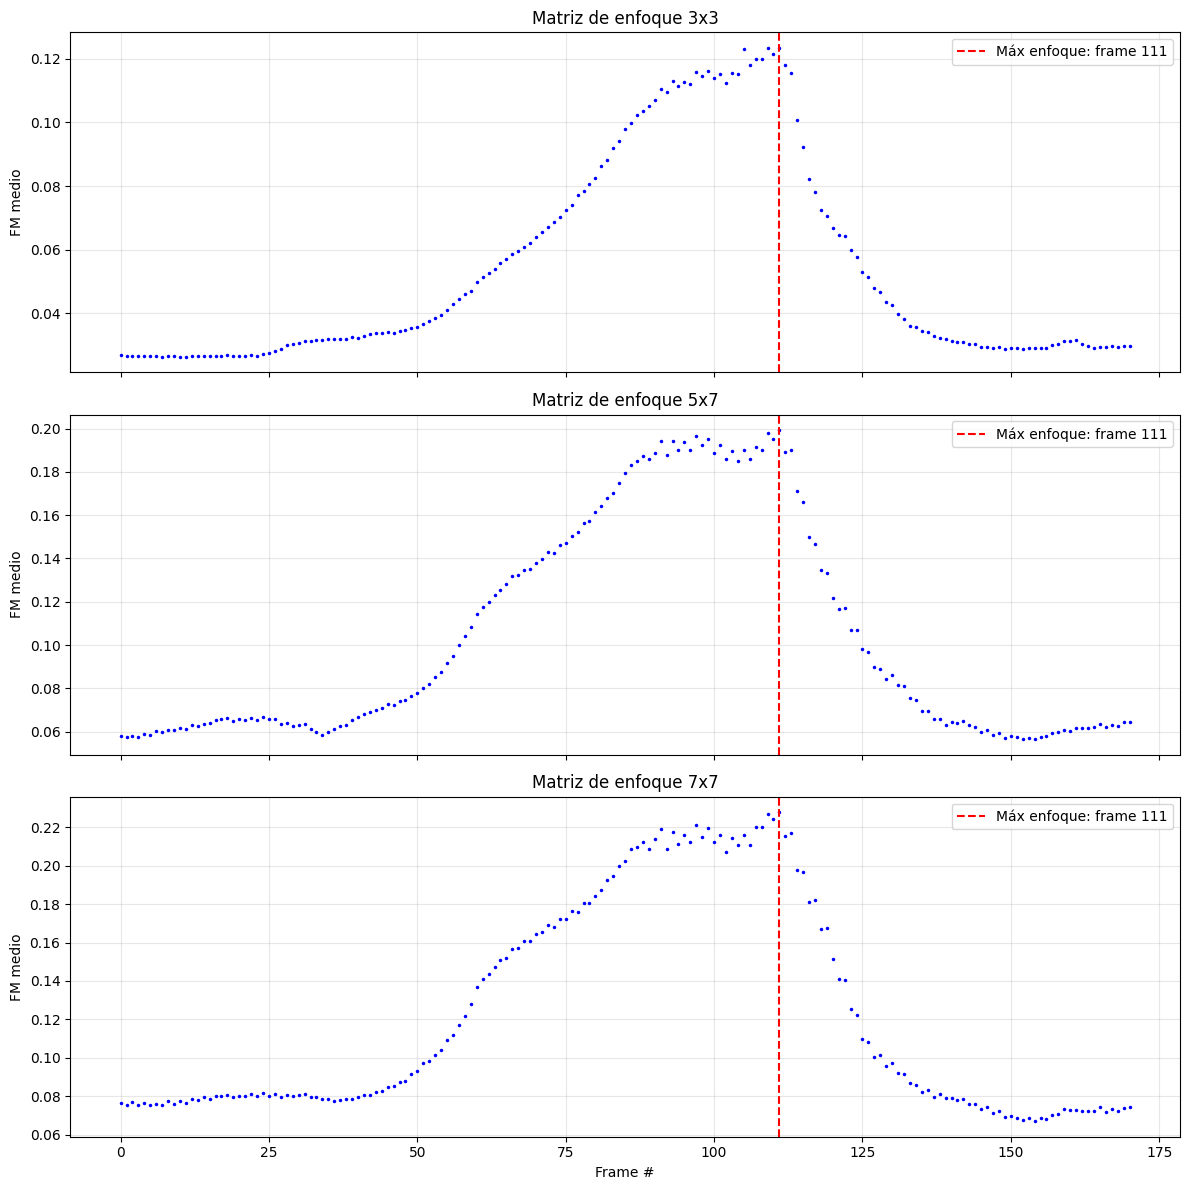

In [15]:
fig, axes = plt.subplots(len(matrix), 1, figsize=(12, 4 * len(matrix)), sharex=True)

for idx, (gr, gc) in enumerate(matrix):
    key = f'{gr}x{gc}'
    vals = fm_matrix_results[key]
    max_f, _ = detect_max_focus(vals)
    axes[idx].plot(vals, 'b.', markersize=3)
    axes[idx].axvline(x=max_f, color='r', linestyle='--', label=f'Máx enfoque: frame {max_f}')
    axes[idx].set_ylabel('FM medio')
    axes[idx].set_title(f'Matriz de enfoque {key}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame #')
plt.tight_layout()
plt.show()

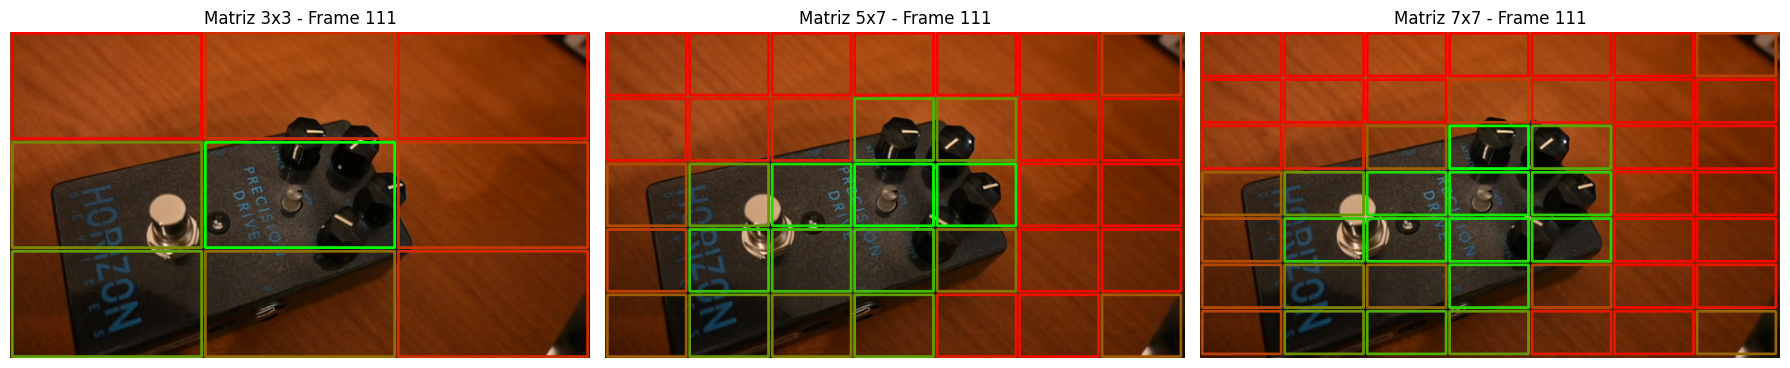

In [27]:
fig, axes = plt.subplots(1, len(matrix), figsize=(6 * len(matrix), 5))

for idx, (gr, gc) in enumerate(matrix):
    key = f'{gr}x{gc}'
    max_f, _ = detect_max_focus(fm_matrix_results[key])
    
    frame_vis = frames_color[max_f].copy()
    h, w = frame_vis.shape[:2]
    cell_h, cell_w = h // gr, w // gc
    
    focus_mat = compute_focus_matrix(frames_gray[max_f], gr, gc)
    fm_min, fm_max = focus_mat.min(), focus_mat.max()
    
    for i in range(gr):
        for j in range(gc):
            x1, y1 = j * cell_w, i * cell_h
            x2, y2 = x1 + cell_w, y1 + cell_h

            if fm_max > fm_min:
                ratio = (focus_mat[i, j] - fm_min) / (fm_max - fm_min)
            else:
                ratio = 1.0
            color = (0, int(255 * ratio), int(255 * (1 - ratio)))
            cv2.rectangle(frame_vis, (x1+2, y1+2), (x2-2, y2-2), color, 2)
    
    axes[idx].imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'Matriz {key} - Frame {max_f}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Al igual que en los experimentos anteriores, podemos observar tanto en los gráficos como en las imágenes que el frame de mayor enfoque es prácticamente el mismo. En este caso, la matriz nos permite observar de mejor manera que en el experimento anterior que el enfoque se concentra en la zona central del video, mostrando las celdas centrales en verde por su mayor nitidez, mientras que las celdas de los bordes aparecen en rojo al corresponder a zonas desenfocadas.

## Punto 2: Métrica alternativa - Laplaciano

Se aplica el operador Laplaciano a la imagen y se calcula la varianza del resultado. Una imagen enfocada produce bordes más definidos, resultando en mayor varianza del Laplaciano.

In [17]:
def compute_laplacian_variance(image_gray):
    laplacian = cv2.Laplacian(image_gray, cv2.CV_64F)
    return laplacian.var()

In [18]:
lap_full = [compute_laplacian_variance(frame) for frame in frames_gray]
max_frame_lap, max_lap = detect_max_focus(lap_full)
print(f'Laplaciano - Frame máx enfoque: {max_frame_lap}, Varianza={max_lap:.2f}')

Laplaciano - Frame máx enfoque: 111, Varianza=109.23


In [19]:
lap_roi_5 = [compute_laplacian_variance(extract_center_roi(f, 0.05)) for f in frames_gray]
lap_roi_10 = [compute_laplacian_variance(extract_center_roi(f, 0.10)) for f in frames_gray]

max_lap5_f, max_lap5_v = detect_max_focus(lap_roi_5)
max_lap10_f, max_lap10_v = detect_max_focus(lap_roi_10)
print(f'Laplaciano ROI 5%  - Frame máx enfoque: {max_lap5_f}, Var={max_lap5_v:.2f}')
print(f'Laplaciano ROI 10% - Frame máx enfoque: {max_lap10_f}, Var={max_lap10_v:.2f}')

Laplaciano ROI 5%  - Frame máx enfoque: 111, Var=449.29
Laplaciano ROI 10% - Frame máx enfoque: 111, Var=427.53


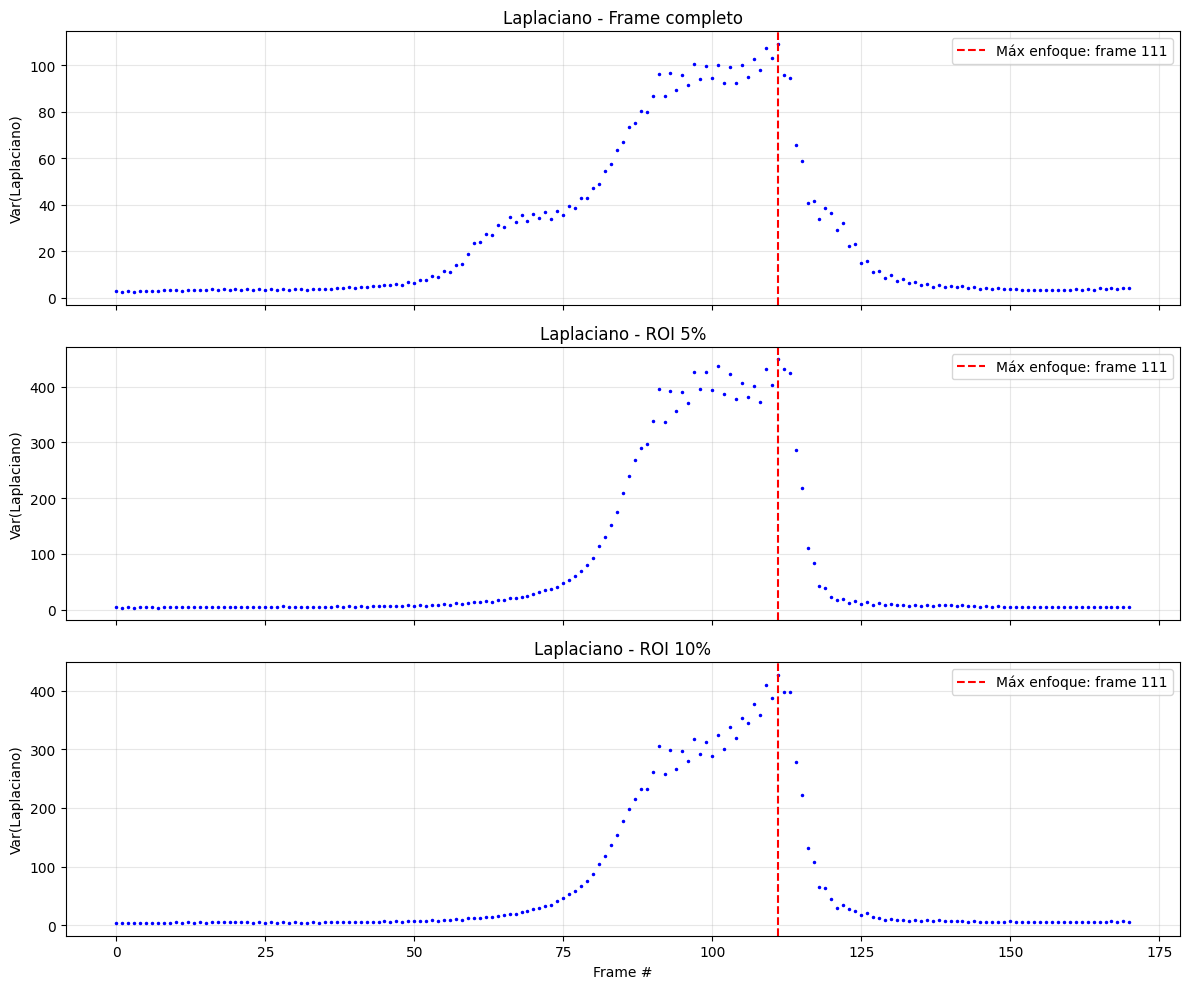

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(lap_full, 'b.', markersize=3)
axes[0].axvline(x=max_frame_lap, color='r', linestyle='--', label=f'Máx enfoque: frame {max_frame_lap}')
axes[0].set_ylabel('Var(Laplaciano)')
axes[0].set_title('Laplaciano - Frame completo')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lap_roi_5, 'b.', markersize=3)
axes[1].axvline(x=max_lap5_f, color='r', linestyle='--', label=f'Máx enfoque: frame {max_lap5_f}')
axes[1].set_ylabel('Var(Laplaciano)')
axes[1].set_title('Laplaciano - ROI 5%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(lap_roi_10, 'b.', markersize=3)
axes[2].axvline(x=max_lap10_f, color='r', linestyle='--', label=f'Máx enfoque: frame {max_lap10_f}')
axes[2].set_xlabel('Frame #')
axes[2].set_ylabel('Var(Laplaciano)')
axes[2].set_title('Laplaciano - ROI 10%')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparación de métricas

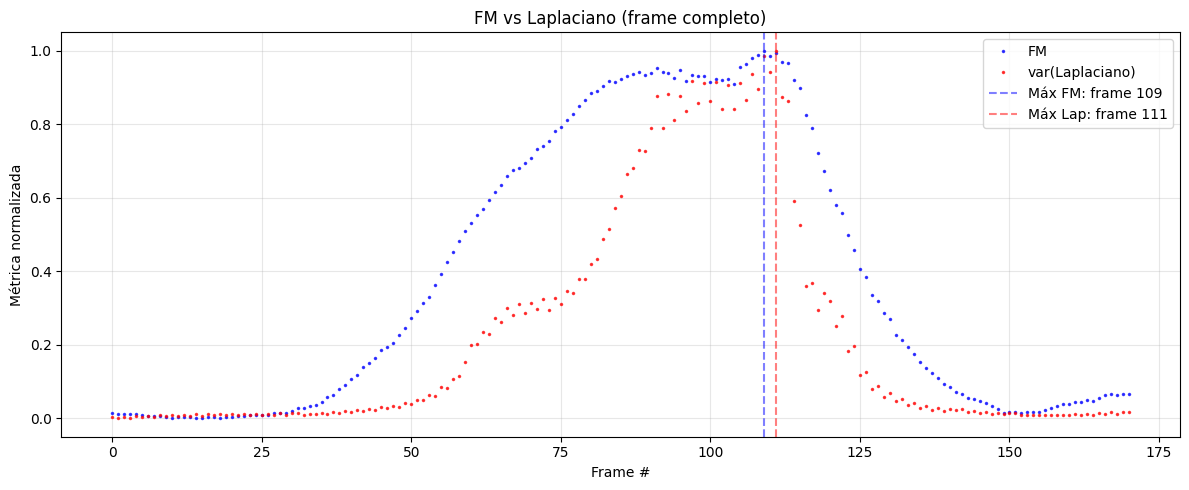

In [28]:
# Normalizamos ambas metricas para comparar en el mismo grafico
def normalize(values):
    v = np.array(values)
    return (v - v.min()) / (v.max() - v.min())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(normalize(fm_full), 'b.', markersize=3, label='FM', alpha=0.7)
ax.plot(normalize(lap_full), 'r.', markersize=3, label='var(Laplaciano)', alpha=0.7)

ax.axvline(x=max_frame_full, color='b', linestyle='--', alpha=0.5, label=f'Máx FM: frame {max_frame_full}')
ax.axvline(x=max_frame_lap, color='r', linestyle='--', alpha=0.5, label=f'Máx Lap: frame {max_frame_lap}')

ax.set_xlabel('Frame #')
ax.set_ylabel('Métrica normalizada')
ax.set_title('FM vs Laplaciano (frame completo)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Hatsa ahora, en todos los experimentos probados, el resultado es casi el mismo: el punto de máximo enfoque se encuentra alrededor de los frames 109-111.

Tanto la métrica FM en dominio de frecuencia como la varianza del Laplaciano coinciden en la detección, lo que nos confirma que el algoritmo funciona correctamente.

## Unsharp Masking

En este punto aplicamos unsharp masking como pre-procesamiento antes de calcular la métrica FM. Esta tiene como objetivo reforzar los bordes de la imagen restando una versión suavizada de sí misma, lo que exagera los detalles y nos permite evaluar si la detección del punto de máximo enfoque se mantiene estable al amplificar la señal de enfoque.

In [22]:
def unsharp_mask(image, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1.0 + strength, blurred, -strength, 0)
    return sharpened

In [23]:
frames_sharpened = [unsharp_mask(frame) for frame in frames_gray]

fm_sharpened = [compute_fm(frame) for frame in frames_sharpened]
max_frame_sharp, max_fm_sharp = detect_max_focus(fm_sharpened)
print(f'Con Unsharp Masking - Frame máx enfoque: {max_frame_sharp}, FM={max_fm_sharp:.4f}')

Con Unsharp Masking - Frame máx enfoque: 111, FM=0.0481


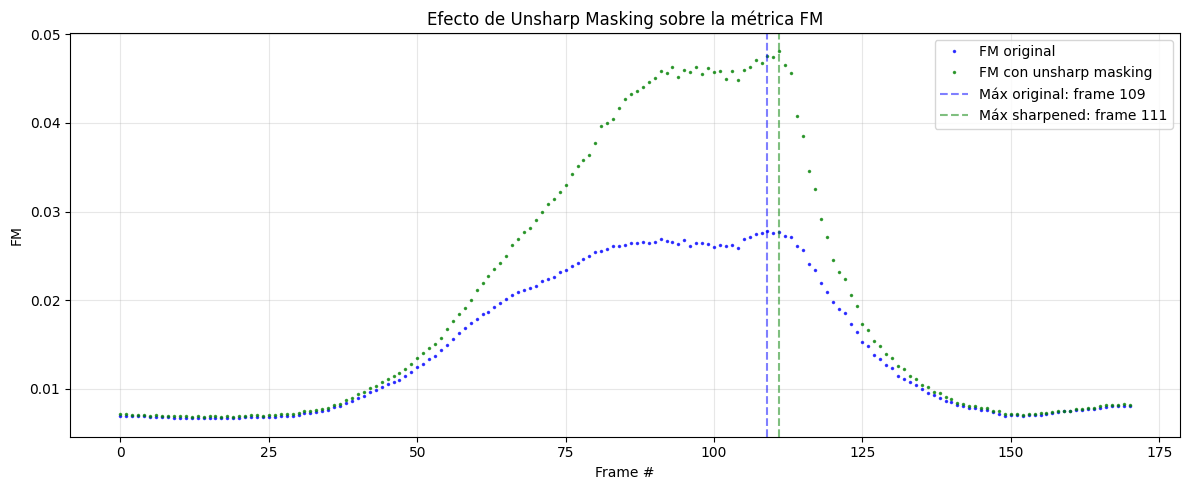

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fm_full, 'b.', markersize=3, label='FM original', alpha=0.7)
ax.plot(fm_sharpened, 'g.', markersize=3, label='FM con unsharp masking', alpha=0.7)

ax.axvline(x=max_frame_full, color='b', linestyle='--', alpha=0.5, label=f'Máx original: frame {max_frame_full}')
ax.axvline(x=max_frame_sharp, color='g', linestyle='--', alpha=0.5, label=f'Máx sharpened: frame {max_frame_sharp}')

ax.set_xlabel('Frame #')
ax.set_ylabel('FM')
ax.set_title('Efecto de Unsharp Masking sobre la métrica FM')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

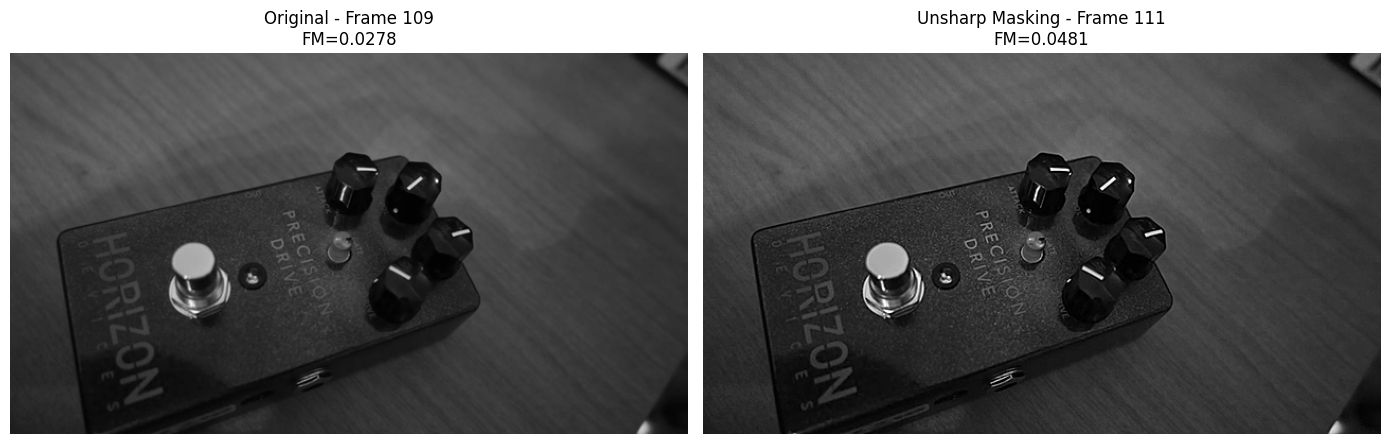

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(frames_gray[max_frame_full], cmap='gray')
axes[0].set_title(f'Original - Frame {max_frame_full}\nFM={fm_full[max_frame_full]:.4f}')
axes[0].axis('off')

axes[1].imshow(frames_sharpened[max_frame_sharp], cmap='gray')
axes[1].set_title(f'Unsharp Masking - Frame {max_frame_sharp}\nFM={fm_sharpened[max_frame_sharp]:.4f}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Podemos observar que el unsharp masking aumenta el valor de FM al reforzar los bordes y detalles de la imagen, pero el frame de máximo enfoque se mantiene, al igual que en todos los otros experimentos, prácticamente igual. Esto nos indica que la métrica FM es robusta y el pre-procesamiento amplifica la señal de nitidez sin alterar la detección del punto óptimo de enfoque.